# TimeGAN baseline aligned with Conv1D Hybrid Detector

In [1]:
import os
import json
import math
import joblib
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

## Reproducibilidad y dispositivo

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Cargar configuración del mejor detector

In [3]:
PROJECT_ROOT = Path("..").resolve()

detector_config_path = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json"

with open(detector_config_path, "r") as f:
    detector_config = json.load(f)

detector_config

{'model_name': 'conv1d_hybrid_ae',
 'best_params_from_optuna': {'window_size': 60,
  'stride': 1,
  'n_conv_layers': 1,
  'conv_channels_1': 64,
  'conv_channels_2': 16,
  'conv_channels_3': 8,
  'kernel_size': 5,
  'disc_hidden_1': 64,
  'disc_hidden_2': 16,
  'fusion_hidden': 256,
  'dropout': 0.01837443752413843,
  'batch_size': 128,
  'lr': 0.00023729585064585673,
  'optimizer': 'Adam',
  'epochs': 30},
 'continuous_cols': ['AIT201.Pv',
  'AIT202.Pv',
  'AIT203.Pv',
  'AIT501.Pv',
  'AIT502.Pv',
  'AIT503.Pv',
  'AIT504.Pv',
  'DPIT301.Pv',
  'FIT101.Pv',
  'FIT201.Pv',
  'FIT301.Pv',
  'FIT401.Pv',
  'FIT501.Pv',
  'FIT502.Pv',
  'FIT503.Pv',
  'FIT504.Pv',
  'FIT601.Pv',
  'LIT101.Pv',
  'LIT301.Pv',
  'LIT401.Pv',
  'PIT501.Pv',
  'PIT502.Pv',
  'PIT503.Pv'],
 'discrete_cols': ['MV101.Status',
  'MV201.Status',
  'MV301.Status',
  'MV302.Status',
  'MV303.Status',
  'MV304.Status',
  'MV501.Status',
  'MV502.Status',
  'MV503.Status',
  'MV504.Status',
  'P101.Status',
  'P201.S

In [4]:
continuous_cols = detector_config["continuous_cols"]
discrete_cols = detector_config["discrete_cols"]
feature_cols = detector_config["feature_cols"]

WINDOW_SIZE = detector_config["window_size"]   # debería ser 60
STRIDE = detector_config["stride"]             # debería ser 1
WARMUP = detector_config["warmup"]

print("Window size:", WINDOW_SIZE)
print("Stride:", STRIDE)
print("Warmup:", WARMUP)
print("Continuous:", len(continuous_cols))
print("Discrete:", len(discrete_cols))

Window size: 60
Stride: 1
Warmup: 120
Continuous: 23
Discrete: 26


## Cargar datos limpios

In [5]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"
file_paths = sorted(clean_folder.glob("*.csv"))

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {fp.stem: load_clean_csv(fp) for fp in file_paths}

print("Archivos cargados:")
list(files.keys())

Archivos cargados:


['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']

## Columnas comunes

In [6]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {name: df[common_cols].copy() for name, df in files.items()}

print("Número de columnas comunes:", len(common_cols))

Número de columnas comunes: 61


## Eliminar filas completamente vacías

In [7]:
temp_feature_cols = [c for c in next(iter(files.values())).columns if c != "t_stamp"]

for name in files:
    before = len(files[name])
    files[name] = files[name].dropna(subset=temp_feature_cols, how="all").reset_index(drop=True)
    after = len(files[name])

    if before != after:
        print(f"{name}: se eliminaron {before - after} filas completamente vacías")

29June2020_2: se eliminaron 1 filas completamente vacías


## Eliminar columnas constantes

In [8]:
profile_rows = []

global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0).reset_index(drop=True)

for col in feature_cols:
    s = global_df[col]
    profile_rows.append({
        "feature": col,
        "type": "continuous" if col in continuous_cols else "discrete",
        "n_unique": s.nunique(dropna=True),
        "missing": int(s.isna().sum()),
        "is_constant": s.nunique(dropna=True) <= 1
    })

profile_df = pd.DataFrame(profile_rows)
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()

constant_cols

[]

In [9]:
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols = [c for c in discrete_cols if c not in constant_cols]
feature_cols = continuous_cols + discrete_cols

print("Continuas restantes:", len(continuous_cols))
print("Discretas restantes:", len(discrete_cols))

Continuas restantes: 23
Discretas restantes: 26


## Warm-up

In [10]:
def remove_warmup(df, warmup_seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    start_time = df["t_stamp"].min()
    return df[df["t_stamp"] >= start_time + pd.Timedelta(seconds=warmup_seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], warmup_seconds=WARMUP)

## Split temporal por archivo

In [11]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [12]:
split_by_file = {}

for name, df_i in files.items():
    df_base = df_i[["t_stamp"] + feature_cols].copy()

    train_i, val_i, test_i = temporal_split(df_base)

    split_by_file[name] = {
        "train": train_i,
        "val": val_i,
        "test": test_i
    }

    print(f"{name}:")
    print("  train:", train_i.shape)
    print("  val:  ", val_i.shape)
    print("  test: ", test_i.shape)

22June2020_1:
  train: (8568, 50)
  val:   (2856, 50)
  test:  (2856, 50)
22June2020_2:
  train: (2088, 50)
  val:   (696, 50)
  test:  (696, 50)
29June2020_1:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1417, 50)
29June2020_2:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1416, 50)


## Escalado de continuas

In [13]:
# ---------------------------------
# Escaladores:
# 1) scaler_cont_detector: mantiene compatibilidad con el detector final
# 2) scaler_cont_timegan: escala continuas a [0,1] para entrenar TimeGAN
# ---------------------------------

scaler_cont_detector = StandardScaler()
scaler_cont_timegan = MinMaxScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file],
    axis=0
)

# Escalador del detector (como ya lo venías usando en detectores)
scaler_cont_detector.fit(train_all_cont)

# Escalador específico para TimeGAN
scaler_cont_timegan.fit(train_all_cont)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [14]:
def scale_split_part(df_part, scaler_cont_timegan, continuous_cols, discrete_cols):
    """
    Para TimeGAN:
    - continuas -> MinMaxScaler [0,1]
    - discretas -> se dejan crudas para luego hacer one-hot por timestep
    """
    cont = pd.DataFrame(
        scaler_cont_timegan.transform(df_part[continuous_cols]),
        columns=continuous_cols,
        index=df_part.index
    )

    disc = df_part[discrete_cols].copy()

    return cont, disc

In [15]:
scaled_split_by_file = {}

for name in split_by_file:
    scaled_split_by_file[name] = {}

    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]

        cont_part, disc_part = scale_split_part(
            df_part=df_part,
            scaler_cont_timegan=scaler_cont_timegan,
            continuous_cols=continuous_cols,
            discrete_cols=discrete_cols
        )

        scaled_split_by_file[name][subset] = {
            "cont": cont_part,
            "disc": disc_part
        }

## Catálogo de categorías discretas usando train

In [16]:
discrete_value_maps = {}

train_disc_global = pd.concat(
    [scaled_split_by_file[name]["train"]["disc"] for name in scaled_split_by_file],
    axis=0
).reset_index(drop=True)

for col in discrete_cols:
    vals = sorted(pd.Series(train_disc_global[col]).dropna().unique().tolist())
    discrete_value_maps[col] = vals

discrete_value_maps

{'MV101.Status': [0.0, 1.0, 2.0],
 'MV201.Status': [0.0, 1.0, 2.0],
 'MV301.Status': [0.0, 1.0, 2.0],
 'MV302.Status': [0.0, 1.0, 2.0],
 'MV303.Status': [0.0, 1.0, 2.0],
 'MV304.Status': [0.0, 1.0, 2.0],
 'MV501.Status': [0.0, 1.0, 2.0],
 'MV502.Status': [0.0, 1.0, 2.0],
 'MV503.Status': [0.0, 1.0, 2.0],
 'MV504.Status': [0.0, 1.0, 2.0],
 'P101.Status': [1.0, 2.0],
 'P201.Status': [1.0, 2.0],
 'P203.Status': [1.0, 2.0],
 'P205.Status': [1.0, 2.0],
 'P301.Status': [1.0, 2.0],
 'P401.Status': [1.0, 2.0],
 'P501.Status': [1.0, 2.0],
 'P601.Status': [1.0, 2.0],
 'P602.Status': [1.0, 2.0],
 'UV401.Status': [1.0, 2.0],
 'P1_STATE': [1.0, 2.0, 3.0],
 'P2_STATE': [1.0, 2.0],
 'P3_STATE': [1.0,
  2.0,
  4.0,
  5.0,
  6.0,
  7.0,
  9.0,
  10.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  99.0],
 'P4_STATE': [1.0, 2.0, 3.0, 4.0],
 'P5_STATE': [1.0,
  3.0,
  4.0,
  5.0,
  6.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  21.0],
 'P6_STATE': [1.0, 2.0]}

In [17]:
onehot_sizes = {col: len(discrete_value_maps[col]) for col in discrete_cols}
total_disc_onehot_dim = sum(onehot_sizes.values())

print("Total one-hot dim discretas:", total_disc_onehot_dim)

Total one-hot dim discretas: 91


## One-hot encoding por timestep

In [18]:
def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    """
    disc_array: np.array con shape (L, n_discrete)
    retorna: np.array con shape (L, total_onehot_dim)
    """
    rows = []

    for t in range(disc_array.shape[0]):
        encoded_t = []

        for j, col in enumerate(discrete_cols):
            value = disc_array[t, j]
            categories = discrete_value_maps[col]

            onehot = np.zeros(len(categories), dtype=np.float32)

            if value in categories:
                idx = categories.index(value)
                onehot[idx] = 1.0

            encoded_t.extend(onehot.tolist())

        rows.append(encoded_t)

    return np.array(rows, dtype=np.float32)

## Construir ventanas por archivo

In [19]:
def build_windows_for_timegan(
    scaled_split_by_file,
    subset,
    continuous_cols,
    discrete_cols,
    discrete_value_maps,
    window_size=60,
    stride=1
):
    cont_windows = []
    disc_windows_raw = []
    disc_windows_onehot = []
    origin_tracker = []

    for name in scaled_split_by_file:
        cont_df = scaled_split_by_file[name][subset]["cont"]
        disc_df = scaled_split_by_file[name][subset]["disc"]

        if len(cont_df) < window_size:
            continue

        cont_arr = cont_df.values.astype(np.float32)
        disc_arr = disc_df.values

        for i in range(0, len(cont_df) - window_size + 1, stride):
            cont_w = cont_arr[i:i+window_size]
            disc_w = disc_arr[i:i+window_size]

            disc_w_onehot = one_hot_encode_discrete_sequence(
                disc_w, discrete_cols, discrete_value_maps
            )

            cont_windows.append(cont_w)
            disc_windows_raw.append(disc_w)
            disc_windows_onehot.append(disc_w_onehot)
            origin_tracker.append(name)

    if len(cont_windows) == 0:
        return None

    return (
        np.array(cont_windows, dtype=np.float32),
        np.array(disc_windows_raw, dtype=object),
        np.array(disc_windows_onehot, dtype=np.float32),
        origin_tracker
    )

## Construir ventanas train/val/test

In [20]:
train_pack = build_windows_for_timegan(
    scaled_split_by_file=scaled_split_by_file,
    subset="train",
    continuous_cols=continuous_cols,
    discrete_cols=discrete_cols,
    discrete_value_maps=discrete_value_maps,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

val_pack = build_windows_for_timegan(
    scaled_split_by_file=scaled_split_by_file,
    subset="val",
    continuous_cols=continuous_cols,
    discrete_cols=discrete_cols,
    discrete_value_maps=discrete_value_maps,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

test_pack = build_windows_for_timegan(
    scaled_split_by_file=scaled_split_by_file,
    subset="test",
    continuous_cols=continuous_cols,
    discrete_cols=discrete_cols,
    discrete_value_maps=discrete_value_maps,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

In [21]:
train_cont_windows, train_disc_windows_raw, train_disc_windows_onehot, train_origin = train_pack
val_cont_windows, val_disc_windows_raw, val_disc_windows_onehot, val_origin = val_pack
test_cont_windows, test_disc_windows_raw, test_disc_windows_onehot, test_origin = test_pack

print("Train cont windows:", train_cont_windows.shape)
print("Train disc raw windows:", train_disc_windows_raw.shape)
print("Train disc onehot windows:", train_disc_windows_onehot.shape)

print("Val cont windows:", val_cont_windows.shape)
print("Val disc onehot windows:", val_disc_windows_onehot.shape)

print("Test cont windows:", test_cont_windows.shape)
print("Test disc onehot windows:", test_disc_windows_onehot.shape)

Train cont windows: (18916, 60, 23)
Train disc raw windows: (18916, 60, 26)
Train disc onehot windows: (18916, 60, 91)
Val cont windows: (6148, 60, 23)
Val disc onehot windows: (6148, 60, 91)
Test cont windows: (6149, 60, 23)
Test disc onehot windows: (6149, 60, 91)


## Dataset final para TimeGAN

In [22]:
train_timegan_data = np.concatenate(
    [train_cont_windows, train_disc_windows_onehot],
    axis=2
)

val_timegan_data = np.concatenate(
    [val_cont_windows, val_disc_windows_onehot],
    axis=2
)

test_timegan_data = np.concatenate(
    [test_cont_windows, test_disc_windows_onehot],
    axis=2
)

print("Train TimeGAN data:", train_timegan_data.shape)
print("Val TimeGAN data:", val_timegan_data.shape)
print("Test TimeGAN data:", test_timegan_data.shape)

Train TimeGAN data: (18916, 60, 114)
Val TimeGAN data: (6148, 60, 114)
Test TimeGAN data: (6149, 60, 114)


## Estadísticas de control de continuas reales

In [23]:
print("Rango continuas TRAIN para TimeGAN:")
print("Min:", train_cont_windows.min())
print("Max:", train_cont_windows.max())

Rango continuas TRAIN para TimeGAN:
Min: 0.0
Max: 1.0


## Dataloader de train para TimeGAN

In [24]:
BATCH_SIZE = 64

train_timegan_tensor = torch.tensor(train_timegan_data, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_timegan_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

## Parámetros base de TimeGAN

In [ ]:
seq_len = WINDOW_SIZE
feature_dim = train_timegan_data.shape[2]

hidden_dim = 64
latent_dim = 64
num_layers = 3

epochs_embedder = 50
epochs_supervisor = 50
epochs_joint = 100

gamma = 1
eta = 200      # peso de la pérdida supervisada en generador/supervisor
lambda_r = 10  # peso de reconstrucción del embedder
lambda_s = 1.0 # peso de la pérdida supervisada en embedder
lambda_m = 100 # peso de moment matching

## Componentes de TimeGAN

In [26]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))

In [27]:
class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        x_tilde, _ = self.rnn(h)
        return self.act(self.fc(x_tilde))

In [28]:
class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(z_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, z):
        e_hat, _ = self.rnn(z)
        return self.act(self.fc(e_hat))

In [29]:
class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))

In [30]:
class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y_hat, _ = self.rnn(h)
        return self.fc(y_hat)

## Inicializar redes

In [31]:
embedder = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

## Losses y optimizadores

In [32]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(list(generator.parameters()) + list(supervisor.parameters()), lr=5e-4)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

## Funciones auxiliares

In [33]:
def random_generator(batch_size, seq_len, z_dim, device):
    return torch.rand(batch_size, seq_len, z_dim, device=device)

In [34]:
def moment_loss(y_true, y_pred):
    mean_loss = torch.mean(torch.abs(torch.mean(y_true, dim=0) - torch.mean(y_pred, dim=0)))
    var_loss = torch.mean(torch.abs(torch.var(y_true, dim=0) - torch.var(y_pred, dim=0)))
    return mean_loss + var_loss

## Fase 1: Entrenamiento del embedder + recovery

In [35]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        e_optimizer.zero_grad()

        h = embedder(x)
        x_tilde = recovery(h)

        e_loss_t0 = mse_loss(x_tilde, x)
        e_loss = 10 * torch.sqrt(e_loss_t0 + 1e-8)

        e_loss.backward()
        e_optimizer.step()

        epoch_loss += e_loss.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | Loss: {epoch_loss:.6f}")

[Embedder] Epoch 10/50 | Loss: 0.986382
[Embedder] Epoch 20/50 | Loss: 0.775800
[Embedder] Epoch 30/50 | Loss: 0.603620
[Embedder] Epoch 40/50 | Loss: 0.472400
[Embedder] Epoch 50/50 | Loss: 0.402647


## Fase 2: entrenamiento del supervisor

In [36]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        s_optimizer.zero_grad()

        with torch.no_grad():
            h = embedder(x)

        h_hat_supervise = supervisor(h)
        s_loss = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])

        s_loss.backward()
        s_optimizer.step()

        epoch_loss += s_loss.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {epoch_loss:.6f}")

[Supervisor] Epoch 10/50 | Loss: 0.000569
[Supervisor] Epoch 20/50 | Loss: 0.000325
[Supervisor] Epoch 30/50 | Loss: 0.000262
[Supervisor] Epoch 40/50 | Loss: 0.000216
[Supervisor] Epoch 50/50 | Loss: 0.000189


## Fase 3: entrenamiento conjunto

In [37]:
joint_g_history = []
joint_d_history = []
joint_e_history = []

In [ ]:
for epoch in range(epochs_joint):
    g_epoch_loss = 0.0
    d_epoch_loss = 0.0
    e_epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)
        batch_size_curr = x.shape[0]

        # ---------------------
        # Train Generator + Supervisor
        # ---------------------
        for _ in range(2):
            g_optimizer.zero_grad()

            h = embedder(x)
            z = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            x_hat = recovery(h_hat)

            y_fake = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u = bce_loss(y_fake, torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            h_supervise = supervisor(h)
            g_loss_s = mse_loss(h[:, 1:, :], h_supervise[:, :-1, :])

            g_loss_v = moment_loss(x, x_hat)

            g_loss = g_loss_u + gamma * g_loss_u_e + eta * torch.sqrt(g_loss_s + 1e-8) + lambda_m * g_loss_v
            g_loss.backward()
            g_optimizer.step()

            # Embedder refinement separado
            e_optimizer.zero_grad()

            h_ref = embedder(x)
            x_tilde = recovery(h_ref)
            h_supervise_ref = supervisor(h_ref)

            g_loss_s_ref = mse_loss(h_ref[:, 1:, :], h_supervise_ref[:, :-1, :])
            e_loss_t0 = mse_loss(x_tilde, x)
            e_loss0 = 10 * torch.sqrt(e_loss_t0 + 1e-8)
            e_loss = lambda_r * e_loss0 + lambda_s * g_loss_s

            e_loss.backward()
            e_optimizer.step()

        # ---------------------
        # Train Discriminator
        # ---------------------
        d_optimizer.zero_grad()

        with torch.no_grad():
            h = embedder(x)
            z = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

        y_real = discriminator(h)
        y_fake = discriminator(h_hat)
        y_fake_e = discriminator(e_hat)

        d_loss_real = bce_loss(y_real, torch.ones_like(y_real))
        d_loss_fake = bce_loss(y_fake, torch.zeros_like(y_fake))
        d_loss_fake_e = bce_loss(y_fake_e, torch.zeros_like(y_fake_e))

        d_loss = d_loss_real + d_loss_fake + gamma * d_loss_fake_e

        if d_loss.item() > 0.15:
            d_loss.backward()
            d_optimizer.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()
        e_epoch_loss += e_loss.item()

    g_epoch_loss /= len(train_loader)
    d_epoch_loss /= len(train_loader)
    e_epoch_loss /= len(train_loader)

    joint_g_history.append(g_epoch_loss)
    joint_d_history.append(d_epoch_loss)
    joint_e_history.append(e_epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} | "
            f"G: {g_epoch_loss:.6f} | D: {d_epoch_loss:.6f} | E: {e_epoch_loss:.6f}"
        )

[Joint] Epoch 10/100 | G: 50.687605 | D: 1.977994 | E: 0.304817
[Joint] Epoch 20/100 | G: 49.021077 | D: 0.872840 | E: 0.266860
[Joint] Epoch 30/100 | G: 26.288631 | D: 1.999974 | E: 0.232287
[Joint] Epoch 40/100 | G: 29.403917 | D: 1.899013 | E: 0.224043
[Joint] Epoch 50/100 | G: 27.838606 | D: 2.721958 | E: 0.198550
[Joint] Epoch 60/100 | G: 25.673857 | D: 2.180784 | E: 0.194914
[Joint] Epoch 70/100 | G: 23.177686 | D: 2.389671 | E: 0.212166
[Joint] Epoch 80/100 | G: 26.526761 | D: 2.236599 | E: 0.172348
[Joint] Epoch 90/100 | G: 29.255928 | D: 1.955309 | E: 0.166742
[Joint] Epoch 100/100 | G: 31.881377 | D: 1.499309 | E: 0.159309


## Curvas de entrenamiento

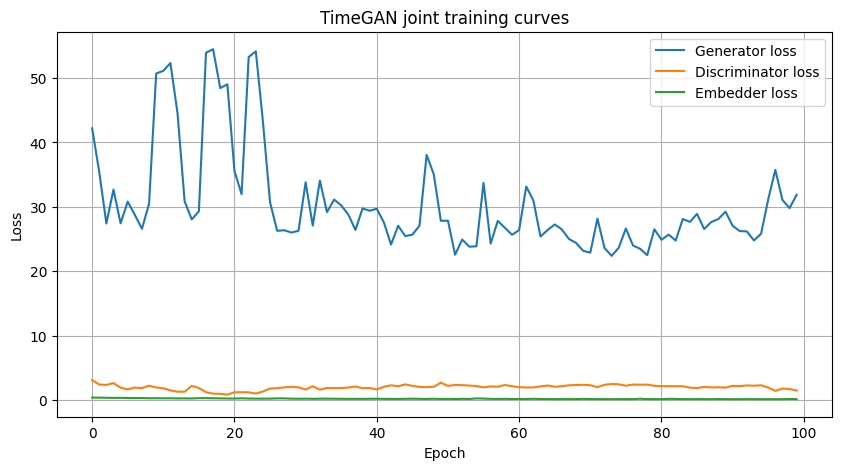

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(joint_g_history, label="Generator loss")
plt.plot(joint_d_history, label="Discriminator loss")
plt.plot(joint_e_history, label="Embedder loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TimeGAN joint training curves")
plt.legend()
plt.grid(True)
plt.show()

## Generar ventanas sintéticas

In [40]:
n_synth = len(train_timegan_data)

with torch.no_grad():
    z = random_generator(n_synth, seq_len, latent_dim, device)
    e_hat = generator(z)
    h_hat = supervisor(e_hat)
    synthetic_windows = recovery(h_hat).cpu().numpy()

In [41]:
print("Synthetic windows shape:", synthetic_windows.shape)

Synthetic windows shape: (18916, 60, 114)


## Separar continuas y discretas sintéticas

In [42]:
n_cont = len(continuous_cols)
n_disc_onehot = total_disc_onehot_dim

synthetic_cont_scaled = synthetic_windows[:, :, :n_cont]
synthetic_disc_onehot = synthetic_windows[:, :, n_cont:n_cont + n_disc_onehot]

print("Synthetic continuous part:", synthetic_cont_scaled.shape)
print("Synthetic discrete onehot part:", synthetic_disc_onehot.shape)

Synthetic continuous part: (18916, 60, 23)
Synthetic discrete onehot part: (18916, 60, 91)


## Decodificar continuas

In [43]:
# ---------------------------------
# Paso 1: salir del espacio [0,1] de TimeGAN hacia escala física real
# ---------------------------------
synthetic_cont_flat = synthetic_cont_scaled.reshape(-1, n_cont)
synthetic_cont_physical = scaler_cont_timegan.inverse_transform(synthetic_cont_flat).reshape(synthetic_cont_scaled.shape)

print("Synthetic continuous in physical scale:", synthetic_cont_physical.shape)

# ---------------------------------
# Paso 2: llevar las continuas sintéticas a la escala que espera el detector final
# (StandardScaler del detector)
# ---------------------------------
synthetic_cont_physical_flat = synthetic_cont_physical.reshape(-1, n_cont)
synthetic_cont_for_detector = scaler_cont_detector.transform(synthetic_cont_physical_flat).reshape(synthetic_cont_scaled.shape)

print("Synthetic continuous prepared for detector:", synthetic_cont_for_detector.shape)

Synthetic continuous in physical scale: (18916, 60, 23)
Synthetic continuous prepared for detector: (18916, 60, 23)


c:\Users\Juan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Decodificar discretas one-hot a secuencia cruda

In [44]:
def decode_onehot_discrete_sequence(onehot_seq, discrete_cols, discrete_value_maps):
    """
    onehot_seq: (L, total_onehot_dim)
    retorna: (L, n_discrete)
    """
    decoded_rows = []

    for t in range(onehot_seq.shape[0]):
        row = []
        cursor = 0

        for col in discrete_cols:
            categories = discrete_value_maps[col]
            k = len(categories)

            block = onehot_seq[t, cursor:cursor+k]
            idx = int(np.argmax(block))
            row.append(categories[idx])

            cursor += k

        decoded_rows.append(row)

    return np.array(decoded_rows, dtype=np.float32)

In [45]:
synthetic_disc_raw = []

for i in range(synthetic_disc_onehot.shape[0]):
    decoded_i = decode_onehot_discrete_sequence(
        synthetic_disc_onehot[i],
        discrete_cols,
        discrete_value_maps
    )
    synthetic_disc_raw.append(decoded_i)

synthetic_disc_raw = np.array(synthetic_disc_raw, dtype=np.float32)

print("Synthetic discrete raw shape:", synthetic_disc_raw.shape)

Synthetic discrete raw shape: (18916, 60, 26)


## Resumen de discretas sintéticas por ventana

In [46]:
def summarize_discrete_windows_from_raw(disc_windows_raw, discrete_cols):
    summary_rows = []

    for w in disc_windows_raw:
        feats = {}

        for j, col in enumerate(discrete_cols):
            values = w[:, j]

            mode_val = pd.Series(values).mode().iloc[0]
            transitions = np.sum(values[1:] != values[:-1])
            nunique = len(np.unique(values))
            dominance = pd.Series(values).value_counts(normalize=True).iloc[0]

            feats[f"{col}__mode"] = mode_val
            feats[f"{col}__transitions"] = transitions
            feats[f"{col}__nunique"] = nunique
            feats[f"{col}__dominance"] = dominance

        summary_rows.append(feats)

    return pd.DataFrame(summary_rows)

In [47]:
synthetic_disc_summary = summarize_discrete_windows_from_raw(
    synthetic_disc_raw,
    discrete_cols
)

print("Synthetic discrete summary shape:", synthetic_disc_summary.shape)
synthetic_disc_summary.head()

Synthetic discrete summary shape: (18916, 104)


,MV101.Status__mode,MV101.Status__transitions,MV101.Status__nunique,MV101.Status__dominance,MV201.Status__mode,MV201.Status__transitions,MV201.Status__nunique,MV201.Status__dominance,MV301.Status__mode,MV301.Status__transitions,...,P4_STATE__nunique,P4_STATE__dominance,P5_STATE__mode,P5_STATE__transitions,P5_STATE__nunique,P5_STATE__dominance,P6_STATE__mode,P6_STATE__transitions,P6_STATE__nunique,P6_STATE__dominance
0,1.0,0,1,1.000000,1.0,1,2,0.966667,1.0,0,...,1,1.0,12.0,1,2,0.983333,2.0,0,1,1.0
1,1.0,0,1,1.000000,2.0,0,1,1.000000,1.0,0,...,1,1.0,1.0,0,1,1.000000,2.0,0,1,1.0
2,1.0,0,1,1.000000,2.0,0,1,1.000000,1.0,0,...,1,1.0,1.0,0,1,1.000000,2.0,0,1,1.0
3,1.0,0,1,1.000000,1.0,2,3,0.966667,1.0,0,...,1,1.0,12.0,1,2,0.983333,2.0,0,1,1.0
4,2.0,2,3,0.966667,2.0,1,2,0.983333,1.0,0,...,1,1.0,12.0,0,1,1.000000,2.0,0,1,1.0


## Verificación de compatibilidad con detector final

In [48]:
# El detector Conv1D híbrido espera continuas estandarizadas con shape (N, C, L)
X_synth_cont = np.transpose(synthetic_cont_for_detector, (0, 2, 1)).astype(np.float32)

# Las discretas resumidas por ventana ya quedan en el formato esperado
X_synth_disc = synthetic_disc_summary.values.astype(np.float32)

print("X_synth_cont shape for detector:", X_synth_cont.shape)
print("X_synth_disc shape for detector:", X_synth_disc.shape)

X_synth_cont shape for detector: (18916, 23, 60)
X_synth_disc shape for detector: (18916, 104)


## Visualización real vs sintético de continuas

In [49]:
def plot_real_vs_synth_continuous_physical(
    train_cont_windows,
    synthetic_cont_physical,
    scaler_cont_timegan,
    col_idx,
    col_name,
    n_steps=60
):
    # train_cont_windows está en espacio [0,1] de TimeGAN
    real_seq_scaled = train_cont_windows[0, :n_steps, :]
    real_seq_physical = scaler_cont_timegan.inverse_transform(real_seq_scaled)[:, col_idx]

    synth_seq_physical = synthetic_cont_physical[0, :n_steps, col_idx]

    plt.figure(figsize=(10, 4))
    plt.plot(real_seq_physical, label="Real (physical)")
    plt.plot(synth_seq_physical, label="Synthetic (physical)")
    plt.title(f"Real vs Synthetic - {col_name}")
    plt.xlabel("Timestep")
    plt.ylabel("Physical value")
    plt.grid(True)
    plt.legend()
    plt.show()

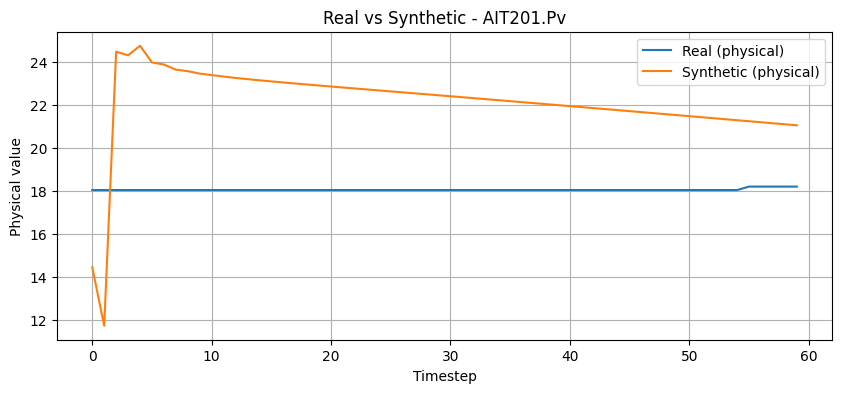

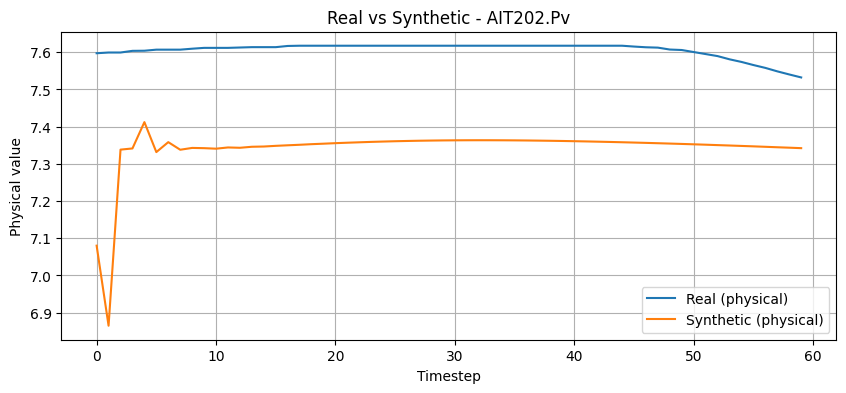

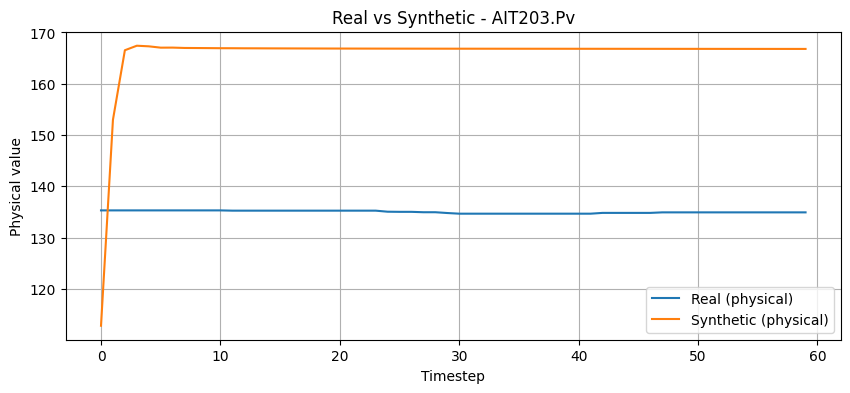

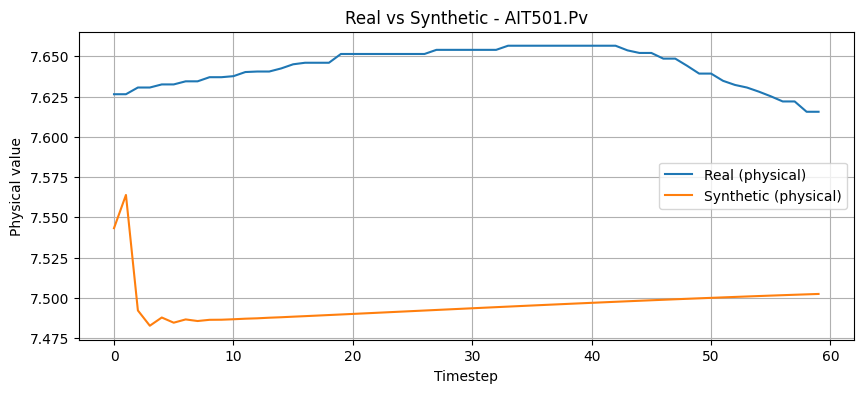

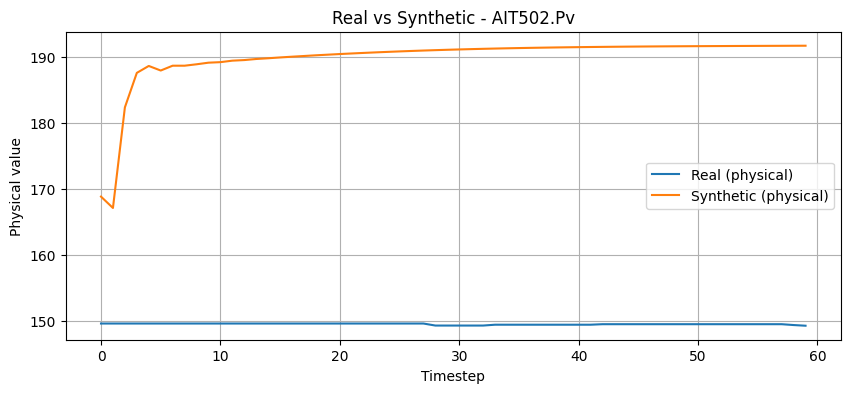

In [50]:
for i, col in enumerate(continuous_cols[:5]):
    plot_real_vs_synth_continuous_physical(
        train_cont_windows=train_cont_windows,
        synthetic_cont_physical=synthetic_cont_physical,
        scaler_cont_timegan=scaler_cont_timegan,
        col_idx=i,
        col_name=col
    )

## Visualización real vs sintético de discretas

In [51]:
def plot_real_vs_synth_discrete(train_disc_raw, synthetic_disc_raw, col_idx, col_name, n_steps=60):
    real_seq = train_disc_raw[0][:n_steps, col_idx]
    synth_seq = synthetic_disc_raw[0][:n_steps, col_idx]

    plt.figure(figsize=(10, 4))
    plt.step(range(len(real_seq)), real_seq, where="post", label="Real")
    plt.step(range(len(synth_seq)), synth_seq, where="post", label="Synthetic", alpha=0.8)
    plt.title(f"Real vs Synthetic - {col_name}")
    plt.xlabel("Timestep")
    plt.ylabel("State")
    plt.grid(True)
    plt.legend()
    plt.show()

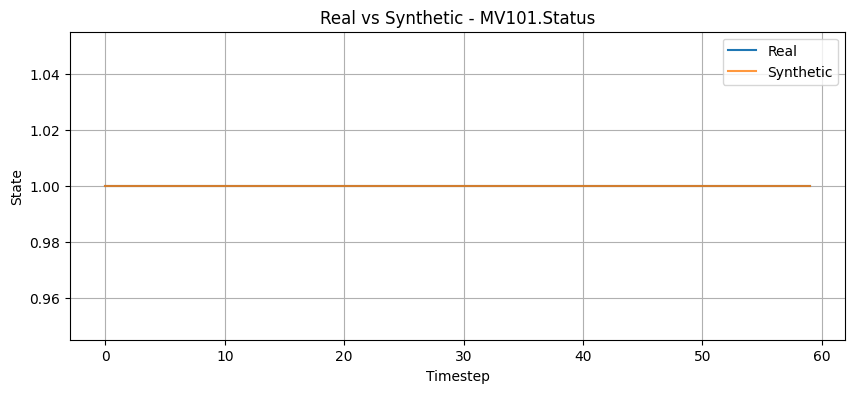

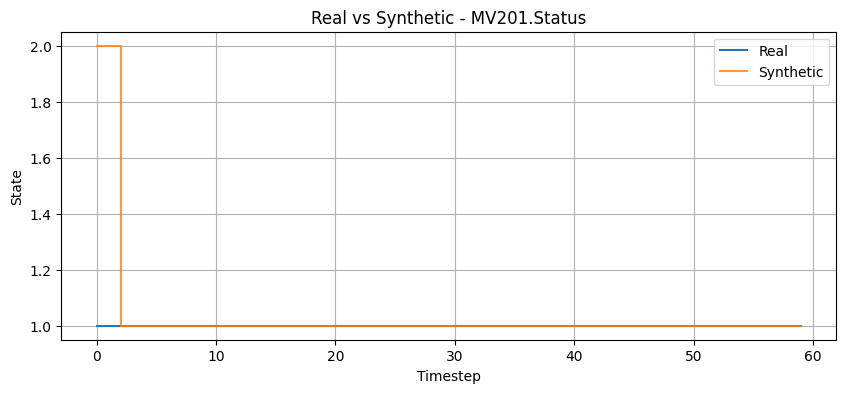

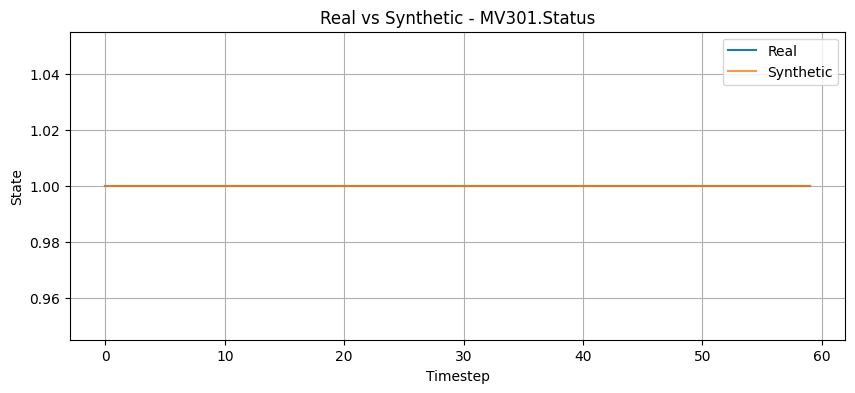

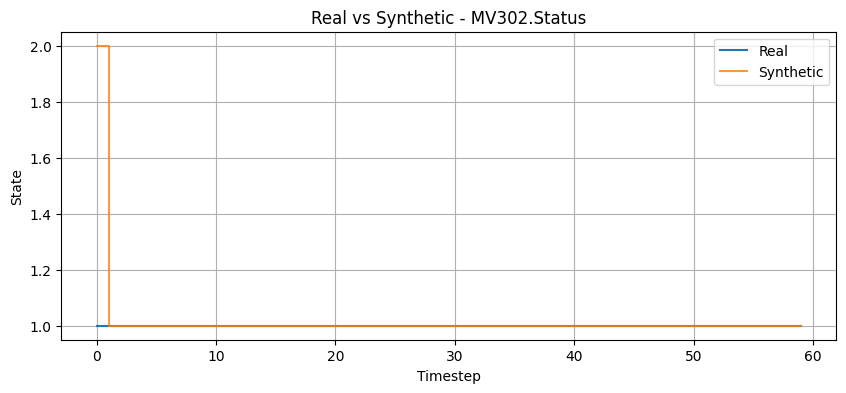

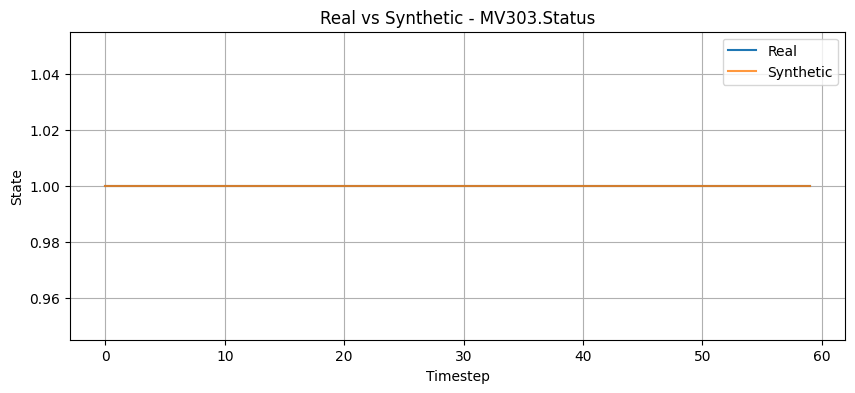

In [52]:
for j, col in enumerate(discrete_cols[:5]):
    plot_real_vs_synth_discrete(train_disc_windows_raw, synthetic_disc_raw, j, col)

## PCA y t-SNE

In [53]:
n_plot = min(500, len(train_timegan_data), len(synthetic_windows))

real_sample = train_timegan_data[:n_plot].reshape(n_plot, -1)
synth_sample = synthetic_windows[:n_plot].reshape(n_plot, -1)

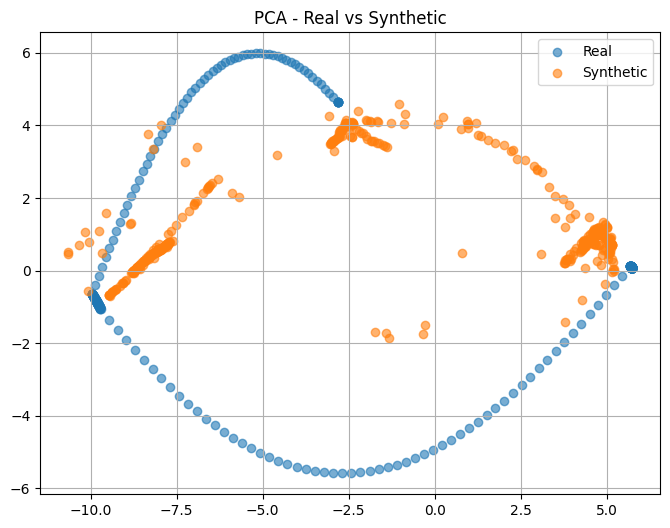

In [54]:
pca = PCA(n_components=2, random_state=SEED)
pca_real = pca.fit_transform(real_sample)
pca_synth = pca.transform(synth_sample)

plt.figure(figsize=(8, 6))
plt.scatter(pca_real[:, 0], pca_real[:, 1], alpha=0.6, label="Real")
plt.scatter(pca_synth[:, 0], pca_synth[:, 1], alpha=0.6, label="Synthetic")
plt.title("PCA - Real vs Synthetic")
plt.legend()
plt.grid(True)
plt.show()

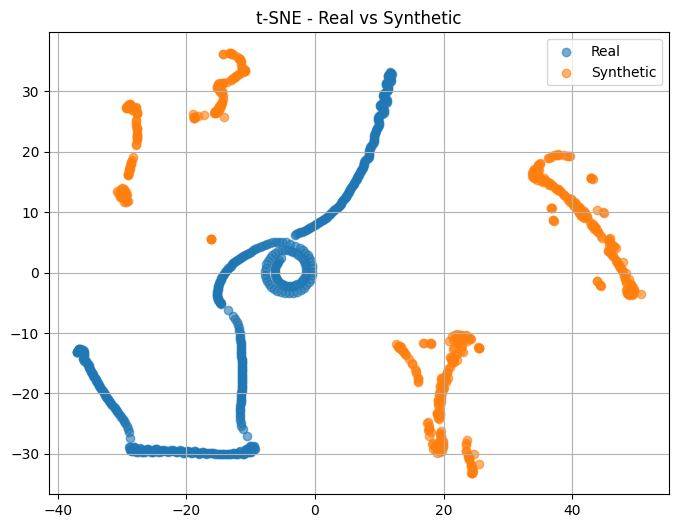

In [55]:
tsne_input = np.vstack([real_sample, synth_sample])
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="random", learning_rate="auto")
tsne_out = tsne.fit_transform(tsne_input)

tsne_real = tsne_out[:n_plot]
tsne_synth = tsne_out[n_plot:]

plt.figure(figsize=(8, 6))
plt.scatter(tsne_real[:, 0], tsne_real[:, 1], alpha=0.6, label="Real")
plt.scatter(tsne_synth[:, 0], tsne_synth[:, 1], alpha=0.6, label="Synthetic")
plt.title("t-SNE - Real vs Synthetic")
plt.legend()
plt.grid(True)
plt.show()

## Estadísticas de control

In [56]:
print("Synthetic full window min/max:", synthetic_windows.min(), synthetic_windows.max())
print("Synthetic continuous [0,1] min/max:", synthetic_cont_scaled.min(), synthetic_cont_scaled.max())
print("Synthetic continuous physical min/max:", synthetic_cont_physical.min(), synthetic_cont_physical.max())
print("Synthetic continuous for detector min/max:", synthetic_cont_for_detector.min(), synthetic_cont_for_detector.max())

Synthetic full window min/max: 5.805158e-23 1.0
Synthetic continuous [0,1] min/max: 2.0692881e-20 1.0
Synthetic continuous physical min/max: 1.152464e-21 1012.3075
Synthetic continuous for detector min/max: -4.0630965 122.468094


In [57]:
real_disc_modes = summarize_discrete_windows_from_raw(train_disc_windows_raw[:200], discrete_cols)
synth_disc_modes = synthetic_disc_summary.iloc[:200].copy()

print("Real discrete summary sample:")
display(real_disc_modes.head())

print("Synthetic discrete summary sample:")
display(synth_disc_modes.head())

Real discrete summary sample:


,MV101.Status__mode,MV101.Status__transitions,MV101.Status__nunique,MV101.Status__dominance,MV201.Status__mode,MV201.Status__transitions,MV201.Status__nunique,MV201.Status__dominance,MV301.Status__mode,MV301.Status__transitions,...,P4_STATE__nunique,P4_STATE__dominance,P5_STATE__mode,P5_STATE__transitions,P5_STATE__nunique,P5_STATE__dominance,P6_STATE__mode,P6_STATE__transitions,P6_STATE__nunique,P6_STATE__dominance
0,1,0,1,1.0,1,0,1,1.0,1,0,...,1,1.0,12,0,1,1.0,2,0,1,1.0
1,1,0,1,1.0,1,0,1,1.0,1,0,...,1,1.0,12,0,1,1.0,2,0,1,1.0
2,1,0,1,1.0,1,0,1,1.0,1,0,...,1,1.0,12,0,1,1.0,2,0,1,1.0
3,1,0,1,1.0,1,0,1,1.0,1,0,...,1,1.0,12,0,1,1.0,2,0,1,1.0
4,1,0,1,1.0,1,0,1,1.0,1,0,...,1,1.0,12,0,1,1.0,2,0,1,1.0


Synthetic discrete summary sample:


,MV101.Status__mode,MV101.Status__transitions,MV101.Status__nunique,MV101.Status__dominance,MV201.Status__mode,MV201.Status__transitions,MV201.Status__nunique,MV201.Status__dominance,MV301.Status__mode,MV301.Status__transitions,...,P4_STATE__nunique,P4_STATE__dominance,P5_STATE__mode,P5_STATE__transitions,P5_STATE__nunique,P5_STATE__dominance,P6_STATE__mode,P6_STATE__transitions,P6_STATE__nunique,P6_STATE__dominance
0,1.0,0,1,1.000000,1.0,1,2,0.966667,1.0,0,...,1,1.0,12.0,1,2,0.983333,2.0,0,1,1.0
1,1.0,0,1,1.000000,2.0,0,1,1.000000,1.0,0,...,1,1.0,1.0,0,1,1.000000,2.0,0,1,1.0
2,1.0,0,1,1.000000,2.0,0,1,1.000000,1.0,0,...,1,1.0,1.0,0,1,1.000000,2.0,0,1,1.0
3,1.0,0,1,1.000000,1.0,2,3,0.966667,1.0,0,...,1,1.0,12.0,1,2,0.983333,2.0,0,1,1.0
4,2.0,2,3,0.966667,2.0,1,2,0.983333,1.0,0,...,1,1.0,12.0,0,1,1.000000,2.0,0,1,1.0


## Guardado de artefactos

In [58]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [59]:
torch.save(embedder.state_dict(), TIMEGAN_MODEL_DIR / "embedder.pt")
torch.save(recovery.state_dict(), TIMEGAN_MODEL_DIR / "recovery.pt")
torch.save(generator.state_dict(), TIMEGAN_MODEL_DIR / "generator.pt")
torch.save(supervisor.state_dict(), TIMEGAN_MODEL_DIR / "supervisor.pt")
torch.save(discriminator.state_dict(), TIMEGAN_MODEL_DIR / "discriminator.pt")

In [60]:
joblib.dump(
    scaler_cont_timegan,
    PROJECT_ROOT / "artifacts" / "scalers" / "timegan_conv1d_hybrid_scaler_cont_minmax.pkl"
)

joblib.dump(
    scaler_cont_detector,
    PROJECT_ROOT / "artifacts" / "scalers" / "timegan_conv1d_hybrid_scaler_cont_detector.pkl"
)

['D:\\Documentos\\Uniandes\\12 Semestre\\PROYECTO DE GRADO\\repoPrincipal\\ics-synthetic-data-augmentation\\artifacts\\scalers\\timegan_conv1d_hybrid_scaler_cont_detector.pkl']

In [61]:
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in discrete_value_maps.items()}, f, indent=4)

In [62]:
timegan_config = {
    "aligned_detector": "conv1d_hybrid_ae",
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "warmup": WARMUP,
    "seed": SEED,
    "hidden_dim": hidden_dim,
    "latent_dim": latent_dim,
    "num_layers": num_layers,
    "epochs_embedder": epochs_embedder,
    "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint,
    "batch_size": BATCH_SIZE,
    "gamma": gamma,
    "train_timegan_shape": list(train_timegan_data.shape),
    "synthetic_windows_shape": list(synthetic_windows.shape),
    "synthetic_cont_scaled_shape": list(synthetic_cont_scaled.shape),
    "synthetic_cont_physical_shape": list(synthetic_cont_physical.shape),
    "synthetic_cont_for_detector_shape": list(synthetic_cont_for_detector.shape),
    "synthetic_disc_raw_shape": list(synthetic_disc_raw.shape),
    "synthetic_disc_summary_shape": list(synthetic_disc_summary.shape),
    "continuous_scaling_for_timegan": "MinMaxScaler",
    "continuous_scaling_for_detector": "StandardScaler",
}

with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(timegan_config, f, indent=4)

In [63]:
training_history_df = pd.DataFrame({
    "epoch": list(range(1, len(joint_g_history) + 1)),
    "generator_loss": joint_g_history,
    "discriminator_loss": joint_d_history,
    "embedder_loss": joint_e_history
})

training_history_df.to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)
training_history_df.head()

,epoch,generator_loss,discriminator_loss,embedder_loss
0,1,42.193768,3.116897,0.406480
1,2,35.410635,2.438788,0.398914
2,3,27.419629,2.372141,0.378492
3,4,32.677407,2.658972,0.358949
4,5,27.451724,1.952736,0.369880


In [64]:
np.save(TIMEGAN_MODEL_DIR / "synthetic_windows.npy", synthetic_windows)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_scaled.npy", synthetic_cont_scaled)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_physical.npy", synthetic_cont_physical)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_for_detector.npy", synthetic_cont_for_detector)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_raw.npy", synthetic_disc_raw)

synthetic_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synthetic_disc_summary.csv", index=False)

print("Artefactos guardados en:", TIMEGAN_MODEL_DIR.resolve())

Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
